In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import config


In [5]:
df = pd.read_csv(config.paths.path_to_train_data, index_col='PassengerId')

In [121]:
df[df['Fare'] > 200].sort_values("Fare")

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
780,1,1,"Robert, Mrs. Edward Scott (Elisabeth Walton Mc...",female,43.0,0,1,24160,211.3375,B3,S
731,1,1,"Allen, Miss. Elisabeth Walton",female,29.0,0,0,24160,211.3375,B5,S
690,1,1,"Madill, Miss. Georgette Alexandra",female,15.0,0,1,24160,211.3375,B5,S
378,0,1,"Widener, Mr. Harry Elkins",male,27.0,0,2,113503,211.5000,C82,C
528,0,1,"Farthing, Mr. John",male,NaN,0,0,PC 17483,221.7792,C95,S
717,1,1,"Endres, Miss. Caroline Louise",female,38.0,0,0,PC 17757,227.5250,C45,C
701,1,1,"Astor, Mrs. John Jacob (Madeleine Talmadge Force)",female,18.0,1,0,PC 17757,227.5250,C62 C64,C
381,1,1,"Bidois, Miss. Rosalie",female,42.0,0,0,PC 17757,227.5250,NaN,C
558,0,1,"Robbins, Mr. Victor",male,NaN,0,0,PC 17757,227.5250,NaN,C


In [3]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    str    
 10  Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 76.7 KB


In [5]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [7]:
df[(df['Pclass'] != 1) & (df['Age'] < 20)]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
15,0,3,"Vestrom, Miss. Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,NaN,S
17,0,3,"Rice, Master. Eugene",male,2.0,4,1,382652,29.1250,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...
853,0,3,"Boulos, Miss. Nourelain",female,9.0,1,1,2678,15.2458,NaN,C
856,1,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S
870,1,3,"Johnson, Master. Harold Theodor",male,4.0,1,1,347742,11.1333,NaN,S


In [125]:
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.', expand=False)
df['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [9]:
df['AgeRange'] = pd.qcut(df['Age'], 5)

df.groupby(['AgeRange'])['Survived'].mean().to_frame()

,Survived
AgeRange,
"(0.419, 19.0]",0.481707
"(19.0, 25.0]",0.328467
"(25.0, 31.8]",0.393701
"(31.8, 41.0]",0.437500
"(41.0, 80.0]",0.373239


In [10]:
df['FareRange'] = pd.qcut(df['Fare'], 5)

df.groupby(['FareRange'])['Survived'].mean().to_frame()

,Survived
FareRange,
"(-0.001, 7.854]",0.217877
"(7.854, 10.5]",0.201087
"(10.5, 21.679]",0.424419
"(21.679, 39.688]",0.444444
"(39.688, 512.329]",0.642045


In [2]:
def generate_continuous_feature(
    data: pd.DataFrame,
    base_col_name: str,
    cat_col_name: str,
    bins: list[list[float]],
) -> pd.DataFrame:
    data = data.copy()
    
    for i, (lo, hi) in enumerate(bins):
        data.loc[(data[base_col_name] > lo) & (data[base_col_name] <= hi), cat_col_name] = i

    data.loc[data[base_col_name] <= bins[0][1], cat_col_name] = 0
    data.loc[data[base_col_name] > bins[-1][0], cat_col_name] = i

    data[cat_col_name] = data[cat_col_name].astype('int64')

    return data
    

In [26]:
FARE_BINS = [
    [-0.001, 7.854],
    [7.854, 10.5],
    [10.5, 21.679],
    [21.679, 39.688],
    [39.688, 512.329],
]

generate_continous_feature(
    df,
    'Fare',
    'FareBin',
    FARE_BINS,
)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FareBin
PassengerId,,,,,,,,,,,,
1,0,0,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0.0
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,4.0
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1.0
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,4.0
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,2.0
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,3.0
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,3.0


In [132]:
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.', expand=False)
df['Title'] = df['Title'].replace(TITLES_DICT)

df[df["Title"] == "Other"]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
PassengerId,,,,,,,,,,,,
150,0,2,"Byles, Rev. Thomas Roussel Davids",male,42.0,0,0,244310,13.000,NaN,S,Other
151,0,2,"Bateman, Rev. Robert James",male,51.0,0,0,S.O.P. 1166,12.525,NaN,S,Other
250,0,2,"Carter, Rev. Ernest Courtenay",male,54.0,1,0,244252,26.000,NaN,S,Other
627,0,2,"Kirkland, Rev. Charles Leonard",male,57.0,0,0,219533,12.350,NaN,Q,Other
648,1,1,"Simonius-Blumer, Col. Oberst Alfons",male,56.0,0,0,13213,35.500,A26,C,Other
695,0,1,"Weir, Col. John",male,60.0,0,0,113800,26.550,NaN,S,Other
823,0,1,"Reuchlin, Jonkheer. John George",male,38.0,0,0,19972,0.000,NaN,S,Other
849,0,2,"Harper, Rev. John",male,28.0,0,1,248727,33.000,NaN,S,Other
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.000,NaN,S,Other


In [122]:
TITLES_DICT = {
    'Mlle': 'Miss',
    'Mme': 'Miss',
    'Ms': 'Miss',
    'Dr': 'Mr',
    'Major': 'Mr',
    'Sir': 'Mr',
    'Capt': 'Mr',
    'Don': 'Mr',
    'Lady': 'Mrs',
    'the Countess': 'Mrs',
    'Jonkheer': 'Other',
    'Col': 'Other',
    'Rev': 'Other',
}

AGE_BY_TITLE_DICT = {
    'Master': 4.57,
    'Miss': 21.86,
    'Mr': 32.74,
    'Mrs': 36,
    'Other': 46,
}

AGE_BINS = [
    [0.419, 20],
    [20.0, 26.0],
    [26.0, 32.74],
    [32.74, 38.0],
    [38.0, 80.0],
]

SEX_DICT = {
    'male': 0,
    'female': 1,
}

EMBARKED_DICT = {
    'S': 0,
    'C': 1,
    'Q': 2,
}

FARE_BINS = [
    [-0.001, 7.854],
    [7.854, 10.5],
    [10.5, 21.679],
    [21.679, 39.688],
    [39.688, 512.329],
]

DROP_COLUMNS = [
    'Name',
    'Ticket',
    'Cabin',
    'Age',
    'Fare',
    'SibSp',
    'Parch',
    'Title',
]

df['Sex'] = (df['Sex'] == 'female').astype('int64')

df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.', expand=False)
df['Title'] = df['Title'].replace(TITLES_DICT)

df['Age'] = df['Age'].fillna(df['Title'].map(AGE_BY_TITLE_DICT))
df = generate_continous_feature(
    df,
    'Age',
    'AgeBin',
    AGE_BINS,
)

df['Embarked'] = df['Embarked'].fillna('S')
df['Embarked'] = df['Embarked'].replace(EMBARKED_DICT).astype('int64')

df = generate_continous_feature(
    df,
    'Fare',
    'FareBin',
    FARE_BINS,
)

df = df.drop(columns=DROP_COLUMNS)



In [123]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Survived  891 non-null    int64
 1   Pclass    891 non-null    int64
 2   Sex       891 non-null    int64
 3   Embarked  891 non-null    int64
 4   AgeBin    891 non-null    int64
 5   FareBin   891 non-null    int64
dtypes: int64(6)
memory usage: 41.9 KB


<Axes: >

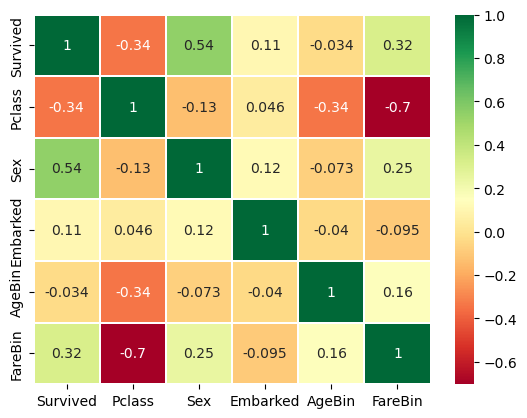

In [56]:
sns.heatmap(df.corr(),annot=True,cmap='RdYlGn',linewidths=0.2,annot_kws={'size':10})

In [87]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, StratifiedKFold

In [115]:
X = df.drop(columns=['Survived'])
y = df['Survived']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=config.general.seed)
model = LogisticRegression(max_iter=1000)
scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

scores

0.7867239972380892 0.024855441872311118


array([0.81564246, 0.76966292, 0.75280899, 0.81460674, 0.78089888])

In [4]:
from config import config
from objects.FeatureTransformer import FeatureTransformer
from objects.DataLoader import DataLoader


data_loader = DataLoader(config)
ft = FeatureTransformer(config)

train = data_loader.load_train()
X, y = data_loader.split_data(train)

ft.fit(X, y)
out = ft.transform(X)

out.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Pclass    891 non-null    int64
 1   Sex       891 non-null    int64
 2   Embarked  891 non-null    int64
 3   FareBin   891 non-null    int64
 4   AgeBin    891 non-null    int64
dtypes: int64(5)
memory usage: 34.9 KB


In [7]:
import pandas as pd
from config import config
from objects.training.Trainer import Trainer

trainer = Trainer(config)

print(trainer.run_cv('KNN'))


{'metric': np.float64(0.7867051660284978), 'metric_std': np.float64(0.02805661348953277), 'fold_metrics': [0.8324022346368715, 0.7752808988764045, 0.7471910112359551, 0.7808988764044944, 0.797752808988764], 'raw': {'fit_time': array([0.01713514, 0.00633717, 0.00456905, 0.00440598, 0.00352693]), 'score_time': array([0.01601696, 0.02689981, 0.00379181, 0.00359011, 0.00332427]), 'test_score': array([0.83240223, 0.7752809 , 0.74719101, 0.78089888, 0.79775281])}}


In [31]:
from dataclasses import dataclass

import numpy as np
from sklearn.base import BaseEstimator
from sklearn.model_selection import GridSearchCV


@dataclass
class SearchResult:
    search: GridSearchCV
    best_score: float
    best_params_full: dict
    best_params_model: dict


def tune_sklearn_model(
    pipeline: BaseEstimator,
    X,
    y,
    param_grid: list[dict] | dict,
    cv,
    scoring: str | dict | None,
    *,
    model_step_name: str = "model",
    n_jobs: int = -1,
    refit: bool | str = True,
    verbose: int = 0,
    error_score: float | str = "raise",
) -> SearchResult:
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        refit=refit,
        verbose=verbose,
        error_score=error_score,
        return_train_score=False,
    )
    search.fit(X, y)

    best_params_full = dict(search.best_params_)
    prefix = f"{model_step_name}__"
    best_params_model = {
        k[len(prefix):]: v for k, v in best_params_full.items()
        if k.startswith(prefix)
    }

    return SearchResult(
        search=search,
        best_score=float(search.best_score_),
        best_params_model=best_params_model,
    )

In [32]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(**config.cv)

result = tune_sklearn_model(
    pipeline=pipeline,
    X=X,
    y=y,
    param_grid=param_grid,
    cv=cv,
    scoring=config.metric,
    model_step_name="model",
    n_jobs=-1,
    verbose=1,
)

print("best_score:", result.best_score)
print("best_params_model:", result.best_params_model)

Fitting 5 folds for each of 220 candidates, totalling 1100 fits
best_score: 0.7878978093026175
best_params_model: {'C': 0.1, 'class_weight': None, 'l1_ratio': 0.7, 'max_iter': 100, 'solver': 'saga'}
best_params_full: {'model__C': 0.1, 'model__class_weight': None, 'model__l1_ratio': 0.7, 'model__max_iter': 100, 'model__solver': 'saga'}


/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/ek5em/python/miniconda3/envs/myenv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio paramete

In [25]:
print('best_score:', search.best_score_)
print('best_params:', best_for_config)


best_score: 0.7957064842131694
best_params: {'C': 0.1, 'class_weight': None, 'l1_ratio': 0.9, 'max_iter': 100, 'solver': 'saga'}


ImportError: cannot import name 'log_run' from 'utils' (/Users/ek5em/python/ml/titanic/utils.py)